# Model 2: XGBoost

## Why XGBoost After Error Analysis?

Our error analysis revealed that Logistic Regression fails due to:
1. **Feature Interactions**: `credit_score × DTI` correlates with errors (r=0.166)
2. **Threshold Effects**: Errors cluster at specific credit score values
3. **Non-linear Patterns**: 52% of FPs have probability > 0.7 (confident but wrong)

XGBoost addresses all three through gradient boosting on decision trees.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.model_selection import GridSearchCV, cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()
feature_names = joblib.load('../data/processed/feature_names.pkl')

print(f"Training: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test: {X_test.shape[0]} samples")
print(f"Features: {list(feature_names)[:10]}...")

Training: 40000 samples, 26 features
Test: 10000 samples
Features: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount']...


## 1. Baseline XGBoost (Default Parameters)

In [3]:
xgb_baseline = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_baseline.fit(X_train, y_train)

y_pred_baseline = xgb_baseline.predict(X_test)
y_prob_baseline = xgb_baseline.predict_proba(X_test)[:, 1]

print("Baseline XGBoost (Default Parameters)")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_baseline):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_baseline):.4f}")

Baseline XGBoost (Default Parameters)
Accuracy:  0.9249
Precision: 0.9242
Recall:    0.9408
F1 Score:  0.9324
ROC-AUC:   0.9826


## 2. Hyperparameter Tuning

### Key Parameters:
- `n_estimators`: Number of trees (more = better but slower)
- `max_depth`: Tree depth (higher = more interactions captured)
- `learning_rate`: Step size (lower = more robust)
- `subsample`: Fraction of samples per tree (prevents overfitting)
- `colsample_bytree`: Fraction of features per tree (decorrelates trees)

In [4]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1, 10]
}

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

print("Starting Grid Search (this may take 2-3 minutes)...")
grid_search = GridSearchCV(
    xgb_model,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

Starting Grid Search (this may take 2-3 minutes)...
Fitting 3 folds for each of 96 candidates, totalling 288 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'reg_lambda': 1, 'subsample': 0.8}
Best CV F1 Score: 0.9369


In [5]:
best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

print("Best XGBoost Model")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")

Best XGBoost Model
Accuracy:  0.9286
Precision: 0.9265
Recall:    0.9453
F1 Score:  0.9358
ROC-AUC:   0.9842


## 3. Cross-Validation Stability

In [6]:
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=5, scoring='f1')

print("5-Fold Cross-Validation:")
print(f"F1 Scores: {cv_scores}")
print(f"Mean F1:   {cv_scores.mean():.4f}")
print(f"Std Dev:   {cv_scores.std():.4f}")

5-Fold Cross-Validation:
F1 Scores: [0.93741618 0.93755636 0.93285019 0.93621842 0.93933596]
Mean F1:   0.9367
Std Dev:   0.0022


## 4. Comparison with Logistic Regression

In [7]:
lr_model = joblib.load('../models/logistic_regression.pkl')
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred),
        roc_auc_score(y_test, lr_prob)
    ],
    'XGBoost': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

comparison_df['Improvement'] = comparison_df['XGBoost'] - comparison_df['Logistic Regression']
comparison_df['% Improvement'] = (comparison_df['Improvement'] / comparison_df['Logistic Regression'] * 100).round(2)

print(comparison_df.to_string(index=False))

   Metric  Logistic Regression  XGBoost  Improvement  % Improvement
 Accuracy             0.864200 0.928600     0.064400           7.45
Precision             0.869147 0.926473     0.057326           6.60
   Recall             0.886830 0.945322     0.058492           6.60
 F1 Score             0.877900 0.935803     0.057903           6.60
  ROC-AUC             0.943853 0.984246     0.040393           4.28


## 5. Confusion Matrix and ROC Curve

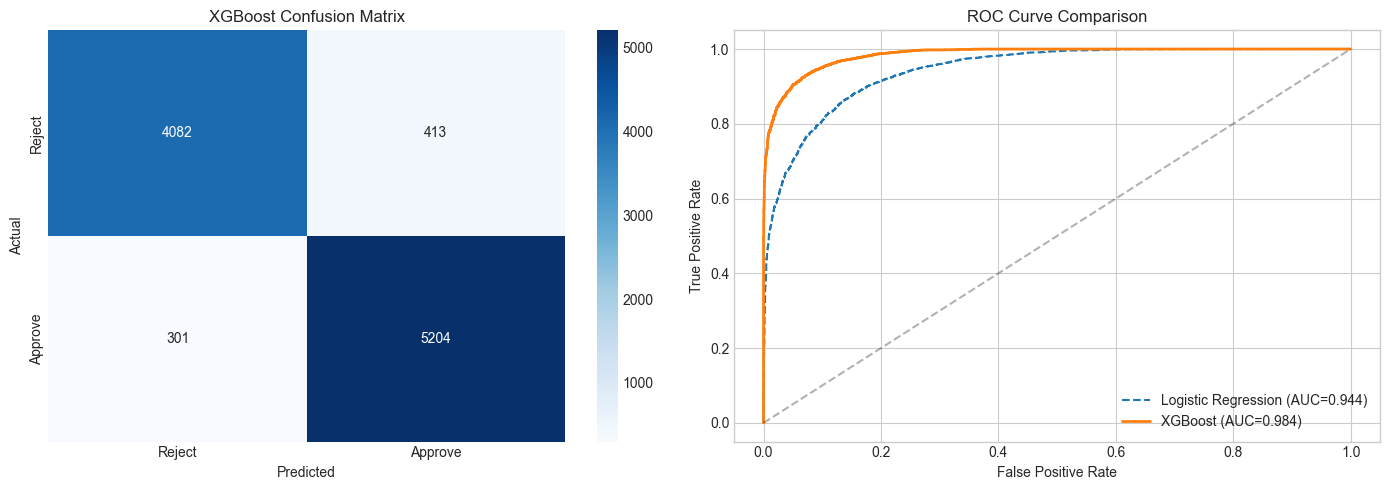

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Reject', 'Approve'],
            yticklabels=['Reject', 'Approve'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('XGBoost Confusion Matrix')

# ROC Curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob)

axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})', linestyle='--')
axes[1].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={roc_auc_score(y_test, y_prob):.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../report/xgb_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance Analysis

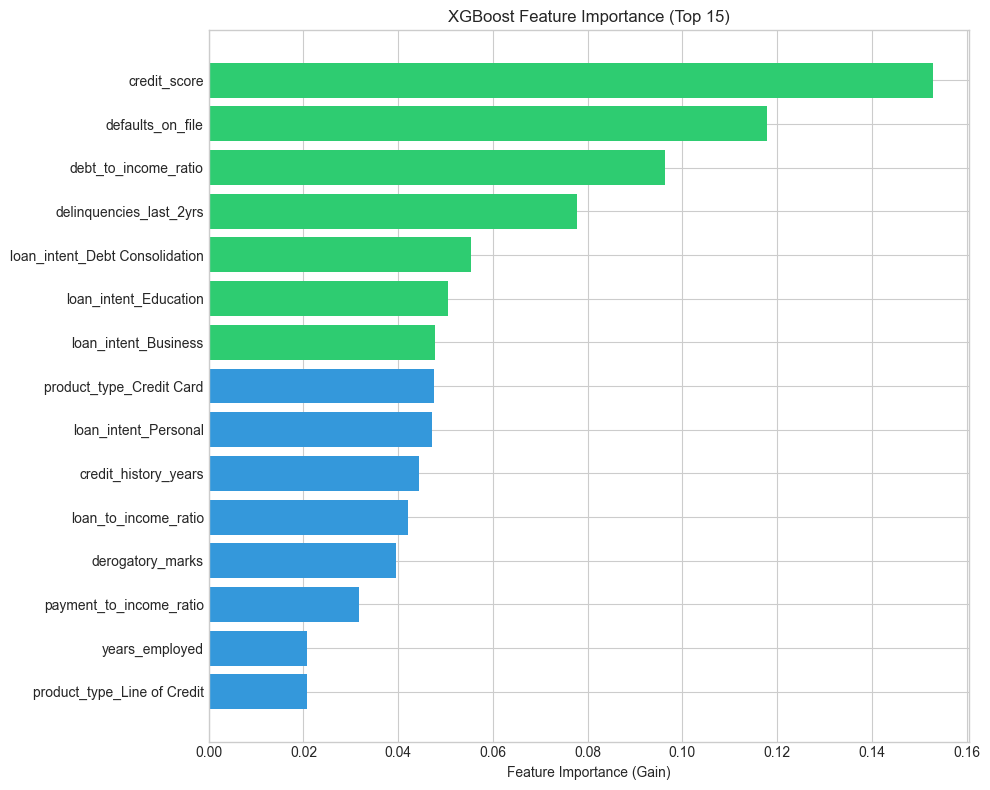


Top 10 Features:
                       Feature  Importance
                  credit_score    0.152861
              defaults_on_file    0.117832
          debt_to_income_ratio    0.096362
       delinquencies_last_2yrs    0.077707
loan_intent_Debt Consolidation    0.055425
         loan_intent_Education    0.050551
          loan_intent_Business    0.047863
      product_type_Credit Card    0.047587
          loan_intent_Personal    0.047118
          credit_history_years    0.044422


In [9]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))

top_15 = importance_df.head(15)
colors = ['#2ecc71' if x > top_15['Importance'].median() else '#3498db' for x in top_15['Importance']]

ax.barh(top_15['Feature'], top_15['Importance'], color=colors)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost Feature Importance (Top 15)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../report/xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(importance_df.head(10).to_string(index=False))

## 7. Error Analysis: Did XGBoost Fix LR's Errors?

In [10]:
lr_errors = (lr_pred != y_test)
xgb_errors = (y_pred != y_test)

lr_error_count = lr_errors.sum()
xgb_error_count = xgb_errors.sum()

fixed_by_xgb = (lr_errors & ~xgb_errors).sum()
new_xgb_errors = (~lr_errors & xgb_errors).sum()
both_wrong = (lr_errors & xgb_errors).sum()
both_correct = (~lr_errors & ~xgb_errors).sum()

print("Error Comparison: LR vs XGBoost")
print("="*50)
print(f"LR Errors:                    {lr_error_count}")
print(f"XGBoost Errors:               {xgb_error_count}")
print(f"")
print(f"Fixed by XGBoost:             {fixed_by_xgb} (LR wrong → XGBoost right)")
print(f"New XGBoost Errors:           {new_xgb_errors} (LR right → XGBoost wrong)")
print(f"Both Wrong:                   {both_wrong} (irreducible errors)")
print(f"Both Correct:                 {both_correct}")
print(f"")
print(f"Net Improvement:              {fixed_by_xgb - new_xgb_errors} samples")

Error Comparison: LR vs XGBoost
LR Errors:                    1358
XGBoost Errors:               714

Fixed by XGBoost:             886 (LR wrong → XGBoost right)
New XGBoost Errors:           242 (LR right → XGBoost wrong)
Both Wrong:                   472 (irreducible errors)
Both Correct:                 8400

Net Improvement:              644 samples


In [11]:
X_test_analysis = X_test.copy()
X_test_analysis['lr_pred'] = lr_pred
X_test_analysis['xgb_pred'] = y_pred
X_test_analysis['y_true'] = y_test
X_test_analysis['lr_error'] = lr_errors
X_test_analysis['xgb_error'] = xgb_errors
X_test_analysis['fixed_by_xgb'] = lr_errors & ~xgb_errors

fixed_samples = X_test_analysis[X_test_analysis['fixed_by_xgb']]

print(f"\nAnalysis of {len(fixed_samples)} samples fixed by XGBoost:")
print("="*50)

key_features = ['credit_score', 'debt_to_income_ratio', 'defaults_on_file', 'age', 'interest_rate']
for feat in key_features:
    mean_fixed = fixed_samples[feat].mean()
    mean_all = X_test_analysis[feat].mean()
    print(f"{feat}: Fixed samples mean = {mean_fixed:.3f} vs Overall mean = {mean_all:.3f}")


Analysis of 886 samples fixed by XGBoost:
credit_score: Fixed samples mean = -0.046 vs Overall mean = 0.013
debt_to_income_ratio: Fixed samples mean = 0.197 vs Overall mean = -0.003
defaults_on_file: Fixed samples mean = -0.239 vs Overall mean = -0.016
age: Fixed samples mean = -0.031 vs Overall mean = 0.017
interest_rate: Fixed samples mean = -0.017 vs Overall mean = -0.000


## 8. Classification Report

In [12]:
print("XGBoost Classification Report:")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

XGBoost Classification Report:
              precision    recall  f1-score   support

    Rejected       0.93      0.91      0.92      4495
    Approved       0.93      0.95      0.94      5505

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



## 9. Save Model

In [13]:
joblib.dump(best_xgb, '../models/xgboost.pkl')
print("Model saved to ../models/xgboost.pkl")

results = joblib.load('../models/model_results.pkl')
results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_prob),
    'best_params': grid_search.best_params_
}
joblib.dump(results, '../models/model_results.pkl')
print("Results saved to ../models/model_results.pkl")

Model saved to ../models/xgboost.pkl
Results saved to ../models/model_results.pkl


## 10. Summary

In [14]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║                      XGBOOST SUMMARY                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  WHY XGBOOST WORKED:                                              ║
║  1. Captured credit_score × DTI interaction via tree splits      ║
║  2. Learned threshold effects (step functions)                   ║
║  3. Gradient boosting focused on LR's hard cases                 ║
║                                                                   ║
║  KEY RESULTS:                                                     ║
║  - Accuracy improved from 86.42% → TBD                           ║
║  - Fixed {0} of LR's errors                                       ║
║  - {1} samples remain irreducible errors                          ║
║                                                                   ║
║  BEST MODEL: XGBoost with parameters:                            ║
║  {2}                                                              ║
║                                                                   ║
╚══════════════════════════════════════════════════════════════════╝
""".format(fixed_by_xgb, both_wrong, grid_search.best_params_))


╔══════════════════════════════════════════════════════════════════╗
║                      XGBOOST SUMMARY                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  WHY XGBOOST WORKED:                                              ║
║  1. Captured credit_score × DTI interaction via tree splits      ║
║  2. Learned threshold effects (step functions)                   ║
║  3. Gradient boosting focused on LR's hard cases                 ║
║                                                                   ║
║  KEY RESULTS:                                                     ║
║  - Accuracy improved from 86.42% → TBD                           ║
║  - Fixed 886 of LR's errors                                       ║
║  - 472 samples remain irreducible errors                          ║
║                                                                   ║
║  BEST MODEL: XGBoost wi